In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

# Blue-toned gradient palette: pastel to dark
custom_palette = ['#a6cfe2', '#7fb3d5', '#2a6f97']

sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': 'lightgrey',
    'axes.linewidth': 0.8,
    'axes.spines.top':False,
    'axes.spines.right':False
})


df = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\EDA\train.csv")

In [2]:
df = df.astype({'Gender': 'str','PreviousCompanies':'str','EducationLevel':'str',
                'RecruitmentStrategy':'str', 'HiringDecision':'str'})

In [3]:
df.describe()

,Age,ExperienceYears,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,35.247500,7.732500,25.764307,51.236667,51.464167,49.760833
std,9.263157,4.663947,14.587675,28.604385,29.409599,29.474128
min,20.000000,0.000000,1.031376,0.000000,0.000000,0.000000
25%,27.000000,4.000000,13.035485,26.000000,26.000000,23.000000
50%,35.000000,8.000000,25.956962,53.000000,53.000000,49.000000
75%,44.000000,12.000000,38.061332,76.000000,77.000000,76.000000
max,50.000000,15.000000,50.992462,100.000000,100.000000,100.000000


In [4]:
df.dtypes

Age                      int64
Gender                  object
EducationLevel          object
ExperienceYears          int64
PreviousCompanies       object
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy     object
HiringDecision          object
dtype: object

In [5]:
dim = df.shape

In [6]:
colnames = df.columns

In [7]:
#df['index'] = np.arange(dim[0])
dfX = pd.DataFrame()
for i in colnames:
    if i != 'HiringDecision':
        dfX[i] = df[i]
dfX.head()


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy
0,34,0,3,12,2,10.376361,46,88,77,1
1,42,1,3,2,2,44.264728,98,75,98,2
2,43,0,1,14,2,28.249114,57,16,44,2
3,48,1,2,0,3,4.446394,35,35,97,3
4,24,1,2,3,5,45.141158,20,25,4,1


In [8]:
from prince import FAMD

In [9]:
famd = FAMD(n_components=10, random_state=42)
famd = famd.fit_transform(dfX)

#print(famd.head())

In [10]:
variance = famd.var()
totalVariance = variance.sum()
varianceProp = variance/totalVariance
varianceProp

component
0    0.105281
1    0.104279
2    0.103283
3    0.101093
4    0.099830
5    0.098781
6    0.098089
7    0.097549
8    0.096724
9    0.095092
dtype: float64

In [11]:
varianceProp[0:6].sum()

0.61254638146581

In [12]:
cumulative_variance = varianceProp.cumsum()
n_components_needed = (cumulative_variance >= 0.80).idxmax() + 1
n_components_needed

8

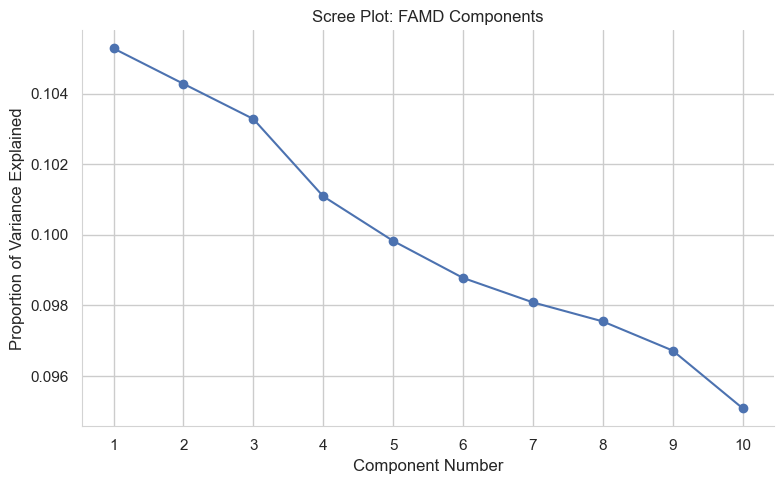

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianceProp) + 1),
         varianceProp, marker='o', linestyle='-')

plt.title("Scree Plot: FAMD Components")
plt.xlabel("Component Number")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(varianceProp) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
# retaining the first 6 components only
dfX_reduc = famd.iloc[:,0:6]
dfX_reduc.head(3)

component,0,1,2,3,4,5
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741


In [30]:
from sklearn.covariance import MinCovDet
from scipy.stats import chi2

mcd = MinCovDet().fit(dfX_reduc)
mahal_dist = mcd.mahalanobis(dfX_reduc)

In [32]:
dfX_reduc['MD'] = mahal_dist
dfX_reduc.head(3)

C:\Users\mpkhd\AppData\Local\Temp\ipykernel_17440\1905597481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfX_reduc['MD'] = mahal_dist


component,0,1,2,3,4,5,MD
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,4.219913
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.699183
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,6.556936


In [34]:
dfXcomp = 6

threshold = chi2.ppf(0.99, dfXcomp)  
dfX_reduc['Outlier'] = dfX_reduc['MD'] > threshold
dfX_reduc.head(3)

C:\Users\mpkhd\AppData\Local\Temp\ipykernel_17440\1733250670.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfX_reduc['Outlier'] = dfX_reduc['MD'] > threshold


component,0,1,2,3,4,5,MD,Outlier
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,4.219913,False
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.699183,False
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,6.556936,False


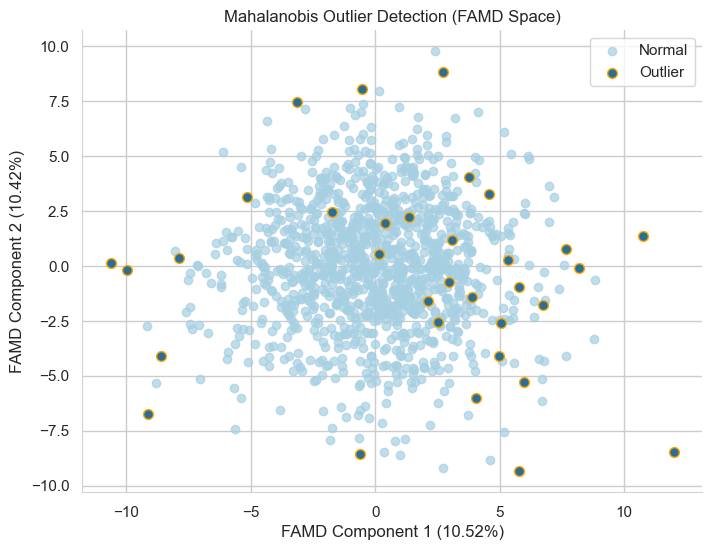

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(dfX_reduc[0][~dfX_reduc['Outlier']], dfX_reduc[1][~dfX_reduc['Outlier']],
    color=custom_palette[0], label='Normal', alpha=0.7)

plt.scatter(dfX_reduc[0][dfX_reduc['Outlier']], dfX_reduc[1][dfX_reduc['Outlier']],
    color=custom_palette[2], label='Outlier', edgecolor='orange', s=50)

plt.xlabel('FAMD Component 1 (10.52%)')
plt.ylabel('FAMD Component 2 (10.42%)')
plt.title('Mahalanobis Outlier Detection (FAMD Space)')
plt.legend()
plt.savefig('MD.png')
plt.show()

In [43]:
dfX_reduc.head()

component,0,1,2,3,4,5,MD,Outlier
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,4.219913,False
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.699183,False
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,6.556936,False
3,-3.471114,2.471557,2.876040,0.403561,1.290109,-1.310014,3.733948,False
4,-4.124790,-3.658183,-4.239462,2.816236,-0.756242,-0.112431,7.259950,False


In [46]:
dfX_reduc['HiringDecision'] = df['HiringDecision']

C:\Users\mpkhd\AppData\Local\Temp\ipykernel_17440\1798909703.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfX_reduc['HiringDecision'] = df['HiringDecision']


In [48]:
dfX_reduc.head()

component,0,1,2,3,4,5,MD,Outlier,HiringDecision
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,4.219913,False,1
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.699183,False,1
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,6.556936,False,0
3,-3.471114,2.471557,2.876040,0.403561,1.290109,-1.310014,3.733948,False,0
4,-4.124790,-3.658183,-4.239462,2.816236,-0.756242,-0.112431,7.259950,False,0


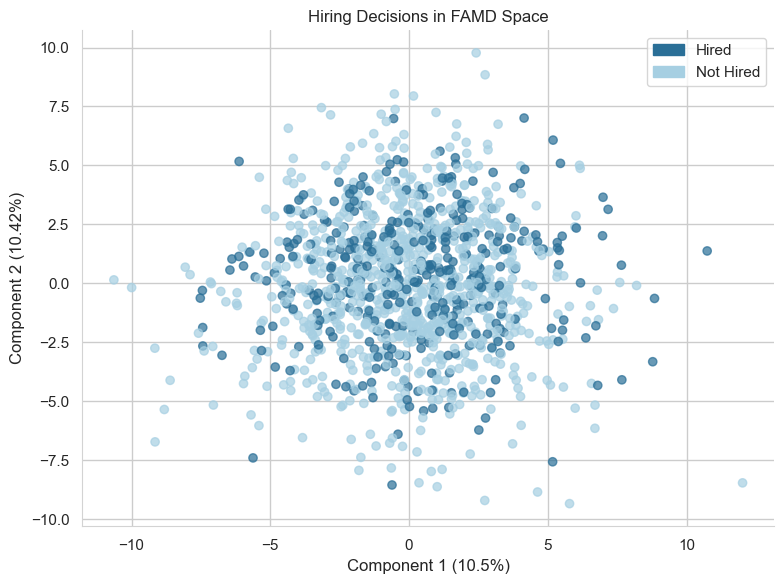

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_map = {'0': custom_palette[0], '1': custom_palette[2]}
colors = dfX_reduc['HiringDecision'].astype(str).map(color_map)

# Create plot
plt.figure(figsize=(8,6))
plt.scatter(dfX_reduc[0], dfX_reduc[1],
            c=colors, alpha=0.7)

# Labels and title
plt.xlabel('Component 1 (10.5%)')
plt.ylabel('Component 2 (10.42%)')
plt.title('Hiring Decisions in FAMD Space')
plt.grid(True)
plt.tight_layout()

# Custom legend using palette colors
legend_handles = [
    mpatches.Patch(color=custom_palette[2], label='Hired'),
    mpatches.Patch(color=custom_palette[0], label='Not Hired')
]
plt.legend(handles=legend_handles)
plt.savefig('HiringDecision.png')
plt.show()

In [52]:
# pip install pingouin

In [54]:
import pingouin as pg

In [68]:
FAMD_dfX = famd.iloc[:,:]
FAMD_dfX.head(3)

component,0,1,2,3,4,5,6,7,8,9
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,-0.231044,-3.143880,-1.341588,-1.081694
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.659575,3.310487,0.771916,0.289917
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,-1.810869,-1.942296,0.423185,1.033421


In [70]:
mardia = pg.multivariate_normality(FAMD_dfX, alpha=0.05)
print(mardia)

HZResults(hz=1.092036371691297, pval=3.2227178881339574e-41, normal=False)


In [77]:
FAMD_dfX['HiringDecision'] = df['HiringDecision']
FAMD_dfX.head()
FAMD_dfX.to_csv("FAMD.csv", index=False)

In [79]:
FAMD_dfX.head()

component,0,1,2,3,4,5,6,7,8,9,HiringDecision
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,-0.231044,-3.143880,-1.341588,-1.081694,1
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.659575,3.310487,0.771916,0.289917,1
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,-1.810869,-1.942296,0.423185,1.033421,0
3,-3.471114,2.471557,2.876040,0.403561,1.290109,-1.310014,-1.859466,0.492388,-0.626834,-1.302526,0
4,-4.124790,-3.658183,-4.239462,2.816236,-0.756242,-0.112431,3.096785,-1.054470,2.016557,-4.446066,0


In [268]:
dfX_reduc.head(3)

component,0,1,2,3,4,5,MD,Outlier,HiringDecision
0,-1.829488,-1.190451,-3.753341,1.007929,3.521377,-0.304926,4.225594,False,1
1,1.726021,-0.899343,0.143157,0.641103,4.592438,1.140132,3.679201,False,1
2,0.837056,2.892360,2.944073,-4.376813,-1.794307,3.250741,6.562448,False,0


In [270]:
df['Outlier'] = dfX_reduc['Outlier']

In [272]:
# Outlier Analysis

dfOut = df[df['Outlier'] == True]

In [274]:
dfOut[dfOut['HiringDecision'] == '1' ]

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision,Outlier
192,49,1,4,6,3,1.595899,12,59,82,2,1,True
281,25,1,3,13,3,31.937349,49,83,96,2,1,True
622,41,0,2,6,4,1.197997,8,10,67,1,1,True
644,45,0,2,13,1,4.083729,26,69,49,1,1,True
862,20,0,1,5,1,14.277880,3,94,70,1,1,True
1012,37,0,4,13,4,27.009730,3,69,68,1,1,True
1021,47,1,3,13,4,12.519332,51,95,84,2,1,True


In [276]:
dfOut[dfOut['HiringDecision'] == '1' ].describe()

,Age,ExperienceYears,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,37.714286,9.857143,13.231702,21.714286,68.428571,73.714286
std,11.205866,3.933979,12.282946,20.830381,29.085261,15.129599
min,20.000000,5.000000,1.197997,3.000000,10.000000,49.000000
25%,31.000000,6.000000,2.839814,5.500000,64.000000,67.500000
50%,41.000000,13.000000,12.519332,12.000000,69.000000,70.000000
75%,46.000000,13.000000,20.643805,37.500000,88.500000,83.000000
max,49.000000,13.000000,31.937349,51.000000,95.000000,96.000000


In [286]:
df.head(3)

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision,Outlier
0,34,0,3,12,2,10.376361,46,88,77,1,1,False
1,42,1,3,2,2,44.264728,98,75,98,2,1,False
2,43,0,1,14,2,28.249114,57,16,44,2,0,False


In [282]:
df[(df['HiringDecision'] == '1') & (df['Outlier'] == False)].describe()


,Age,ExperienceYears,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,35.271233,8.632877,25.115635,58.767123,59.868493,57.772603
std,9.293763,4.379901,14.614132,29.392812,27.090796,29.712641
min,20.000000,0.000000,1.243420,0.000000,0.000000,0.000000
25%,27.000000,6.000000,11.984107,34.000000,40.000000,30.000000
50%,35.000000,9.000000,24.816118,66.000000,64.000000,64.000000
75%,44.000000,12.000000,37.234813,83.000000,82.000000,84.000000
max,50.000000,15.000000,50.992462,100.000000,100.000000,100.000000


In [150]:
from scipy.stats import chi2_contingency

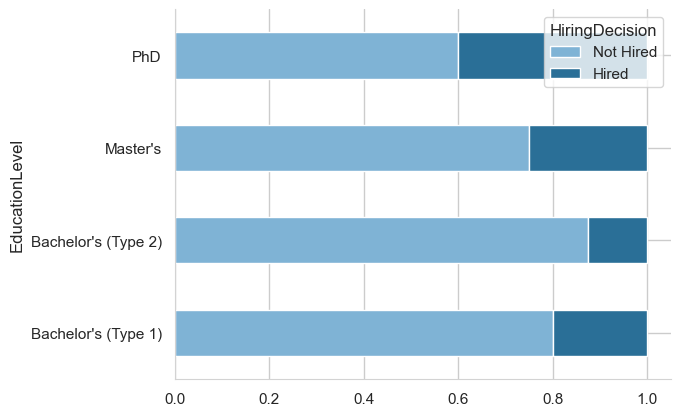

In [205]:
custom_palette = ['#7fb3d5', '#2a6f97']
EHCounts = pd.crosstab(dfOut['EducationLevel'], dfOut['HiringDecision'])
EH = EHCounts.div(EHCounts.sum(axis = 1), axis = 0)

EH.rename(index={
    '1': "Bachelor's (Type 1)",
    '2': "Bachelor's (Type 2)",
    '3': "Master's",
    '4': "PhD"
}, columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
EH.plot(kind = 'barh', stacked = True, color=custom_palette)
plt.xticks(rotation=0)
plt.savefig('EducationOutlier.png')
plt.show()

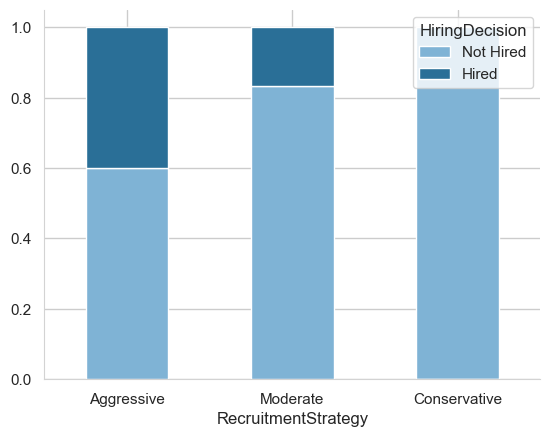

In [207]:
RHCounts = pd.crosstab(dfOut['RecruitmentStrategy'], dfOut['HiringDecision'])
RH = RHCounts.div(RHCounts.sum(axis = 1), axis = 0)
RH.rename(index={
    '1': 'Aggressive',
    '2': 'Moderate',
    '3': 'Conservative'
}, columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
RH.plot(kind = 'bar', stacked = True, color=custom_palette)
plt.xticks(rotation=0)
plt.savefig('RecruitmentStratOutlier.png')
plt.show()

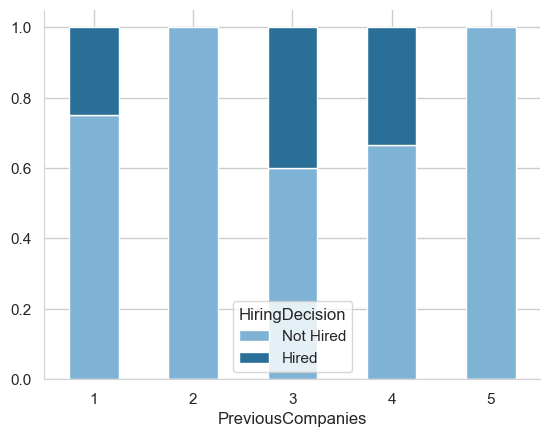

In [209]:
HPCounts = pd.crosstab(dfOut['PreviousCompanies'], dfOut['HiringDecision'])
HP = HPCounts.div(HPCounts.sum(axis = 1), axis = 0)

HP.rename(columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
HP.plot(kind = 'bar', stacked = True, color=custom_palette)
plt.xticks(rotation=0)
plt.savefig('PreviousCompaniesOutlier.png')
plt.show()

In [290]:
dfH = df[df['HiringDecision'] == '1']

C:\Users\mpkhd\AppData\Local\Temp\ipykernel_14308\3674921627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlier', y='InterviewScore', data=dfH, palette=['#7fb3d5', '#2a6f97'])  # Using your custom palette


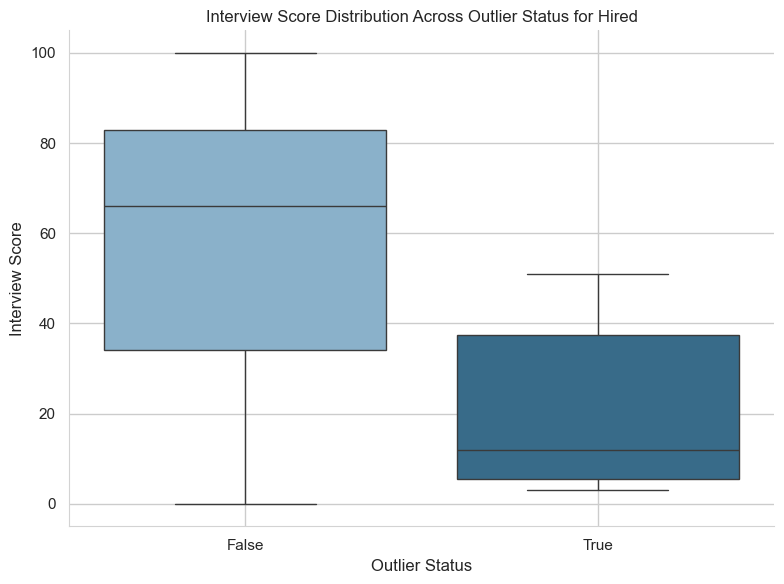

In [306]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outlier', y='InterviewScore', data=dfH, palette=['#7fb3d5', '#2a6f97'])  # Using your custom palette
plt.title('Interview Score Distribution Across Outlier Status for Hired')
plt.ylabel('Interview Score')
plt.xlabel('Outlier Status')
plt.grid(True)
plt.tight_layout()
plt.savefig('InterviewScoreHired.png')
plt.show()

C:\Users\mpkhd\AppData\Local\Temp\ipykernel_14308\3460403657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlier', y='SkillScore', data=dfH, palette=['#7fb3d5', '#2a6f97'])  # Using your custom palette


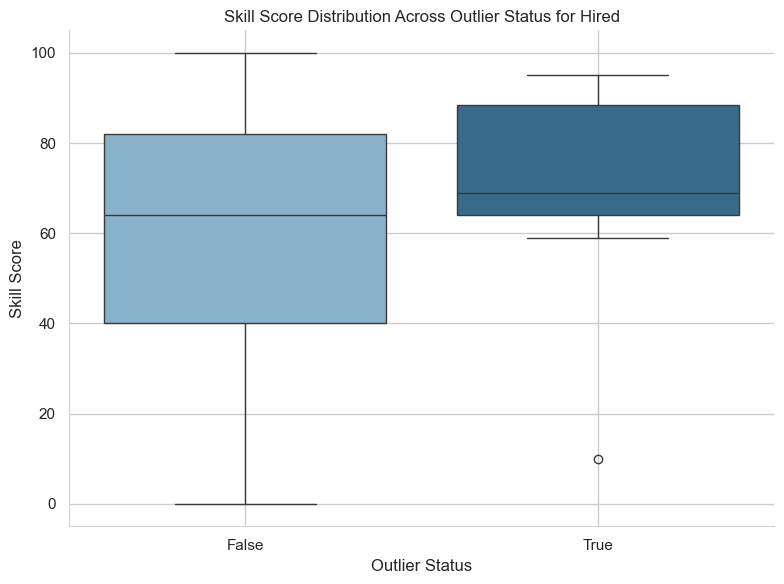

In [308]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outlier', y='SkillScore', data=dfH, palette=['#7fb3d5', '#2a6f97'])  # Using your custom palette
plt.title('Skill Score Distribution Across Outlier Status for Hired')
plt.ylabel('Skill Score')
plt.xlabel('Outlier Status')
plt.grid(True)
plt.tight_layout()
plt.savefig('SkillScoreHired.png')
plt.show()

C:\Users\mpkhd\AppData\Local\Temp\ipykernel_14308\3432599790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlier', y='PersonalityScore', data=dfH, palette=['#7fb3d5', '#2a6f97'])  # Using your custom palette


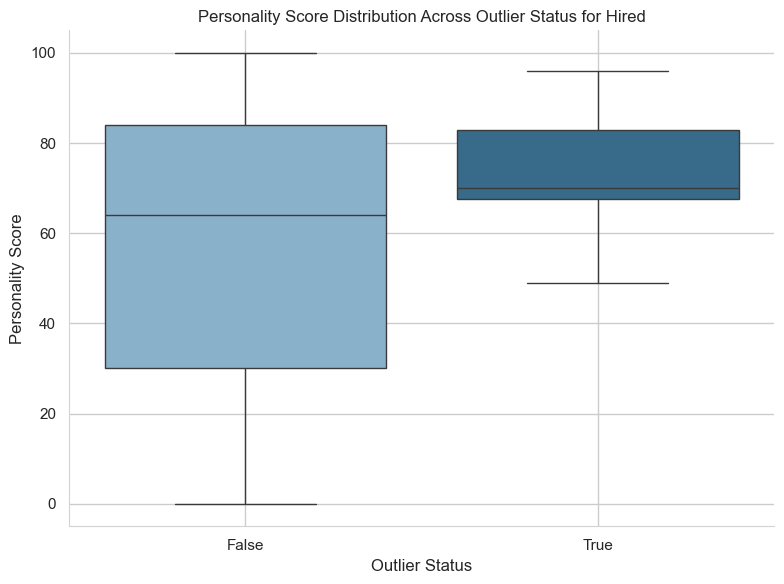

In [310]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outlier', y='PersonalityScore', data=dfH, palette=['#7fb3d5', '#2a6f97'])  # Using your custom palette
plt.title('Personality Score Distribution Across Outlier Status for Hired')
plt.ylabel('Personality Score')
plt.xlabel('Outlier Status')
plt.grid(True)
plt.tight_layout()
plt.savefig('PersonalityScoreHired.png')
plt.show()